In [1]:
#importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [2]:
bigmart_data = pd.read_csv('/content/big_mart_data.csv')

In [3]:
bigmart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
# Item_Identifier (FD -> Food , DR -> Drink , NC -> Non-Consumable)

In [5]:
bigmart_data.shape

(8523, 12)

In [6]:
bigmart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
bigmart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Handling Missing Values

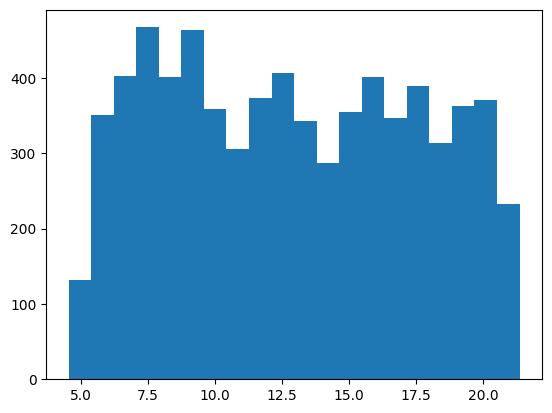

In [8]:
plt.hist(bigmart_data['Item_Weight'], bins=20)
#"Divide the entire range of the column into 20 equal-width intervals and count how many values fall into each interval."
plt.show()
#the plot is somewhat like a mirror image from center -> so not skewed -> we can use MEAN as Imputation

In [9]:
bigmart_data['Item_Weight'].skew()
# 0 → Perfectly symmetric
# -0.5 to +0.5 → Approximately symmetric
# Less than -0.5 or greater than +0.5 → Skewed

np.float64(0.0824262091221237)

In [10]:
#mean of 'Item_Weight'
bigmart_data['Item_Weight'].mean()

np.float64(12.857645184135976)

In [11]:
bigmart_data['Item_Weight'] = bigmart_data['Item_Weight'].fillna(bigmart_data['Item_Weight'].mean())

In [12]:
bigmart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [13]:
bigmart_data['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [14]:
bigmart_data['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


In [15]:
#Finding the most common (MODE) Outlet_Size for each Outlet_Type
mode_of_outlet_size = bigmart_data.pivot_table(values='Outlet_Size',columns='Outlet_Type',aggfunc=(lambda x: x.mode()[0]))

In [16]:
print(mode_of_outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [17]:
#we can find MODE with groupby() also
group_by_mode = bigmart_data.groupby('Outlet_Type')['Outlet_Size'].agg(lambda x: x.mode()[0])
print(group_by_mode)

Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object


In [18]:
#or we can check like this also
pd.crosstab(bigmart_data['Outlet_Type'],
            bigmart_data['Outlet_Size'])

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,528
Supermarket Type1,932,930,1860
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


In [19]:
missing_values = bigmart_data['Outlet_Size'].isnull()

In [20]:
print(missing_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [21]:
bigmart_data.loc[missing_values,'Outlet_Size'] = bigmart_data.loc[missing_values,'Outlet_Type'].apply(lambda x: mode_of_outlet_size[x])

In [22]:
bigmart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [23]:
bigmart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Numerical Features

In [24]:
bigmart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [25]:
# making grid lines for easier viewing
sns.set()

/tmp/ipykernel_17098/1633432170.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bigmart_data['Item_Weight'])


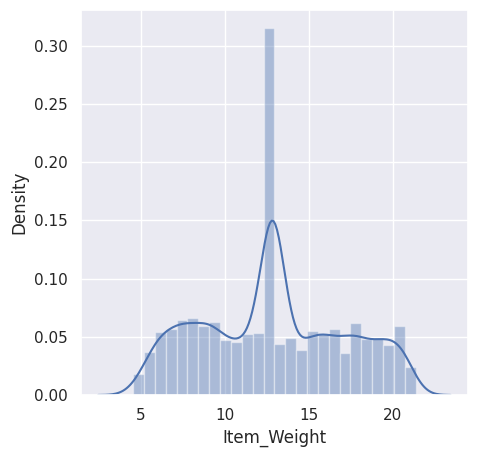

In [26]:
#Item_Weight distribution
plt.figure(figsize=(5,5))
sns.distplot(bigmart_data['Item_Weight'])
plt.show()

/tmp/ipykernel_17098/2412043847.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bigmart_data['Item_Visibility'])


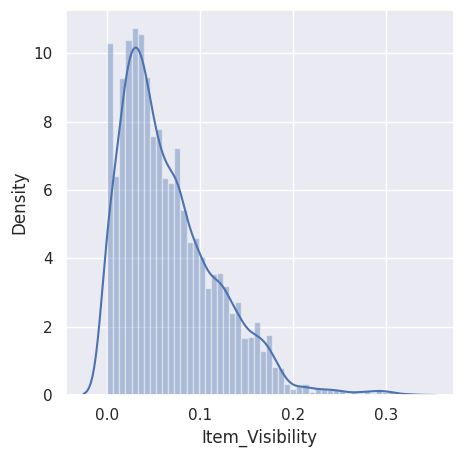

In [27]:
#Item_Visibility distribution
plt.figure(figsize=(5,5))
sns.distplot(bigmart_data['Item_Visibility'])
plt.show()

/tmp/ipykernel_17098/2723901628.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bigmart_data['Item_MRP'])


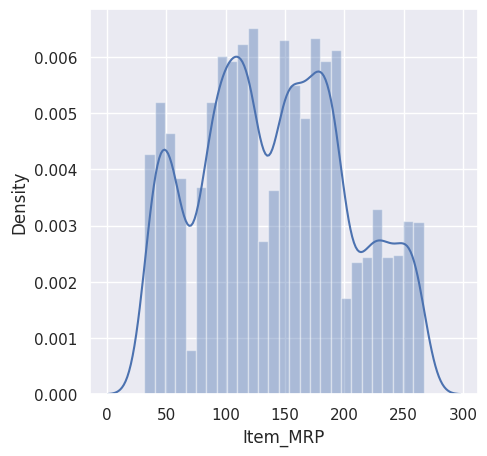

In [28]:
#Item_MRP distribution
plt.figure(figsize=(5,5))
sns.distplot(bigmart_data['Item_MRP'])
plt.show()

/tmp/ipykernel_17098/3857363278.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bigmart_data['Item_Outlet_Sales'])


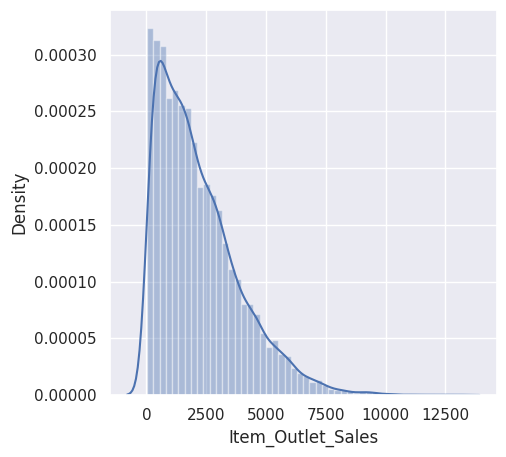

In [29]:
#Item_Outlet_Sales distribution
plt.figure(figsize=(5,5))
sns.distplot(bigmart_data['Item_Outlet_Sales'])
plt.show()

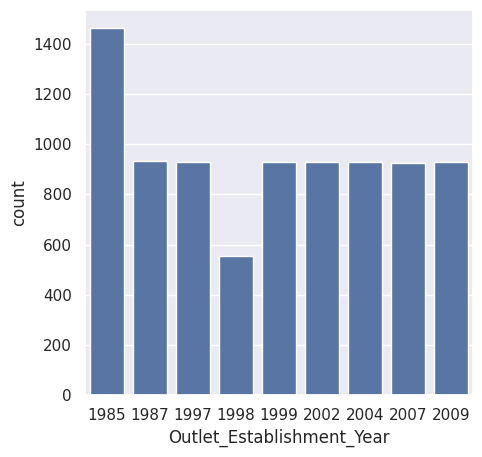

In [30]:
#Outlet_Establishment_Year distribution
plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Establishment_Year',data = bigmart_data)
plt.show()

Categorical Features

- Item_Identifier
- Item_Fat_Content
- Item_Type
- Outlet_Identifier
- Outlet_Size
- Outlet_Location_Type
- Outlet_Type

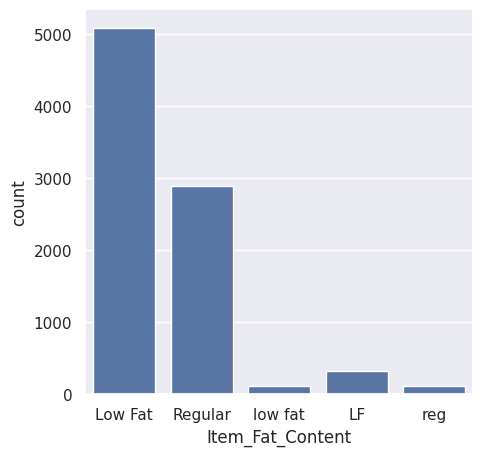

In [31]:
#Item_Fat_Content distribution
plt.figure(figsize=(5,5))
sns.countplot(x='Item_Fat_Content',data = bigmart_data)
plt.show()

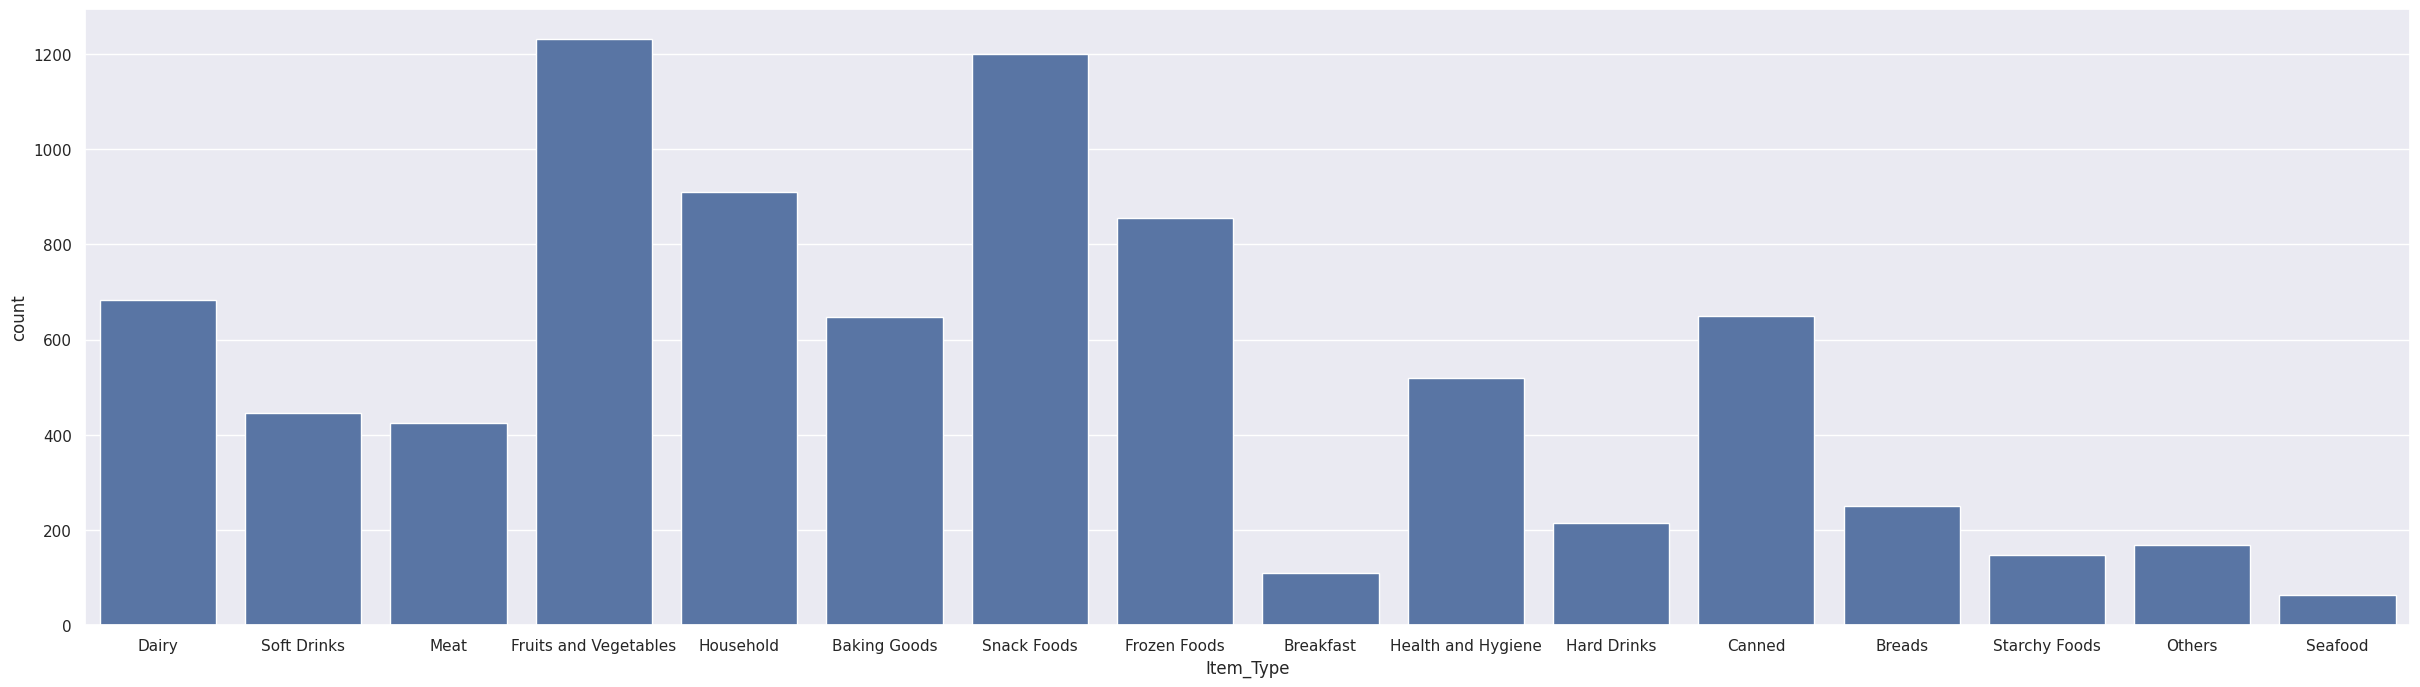

In [32]:
#Item_Type distribution
plt.figure(figsize=(30,8))
sns.countplot(x='Item_Type',data = bigmart_data)
plt.show()

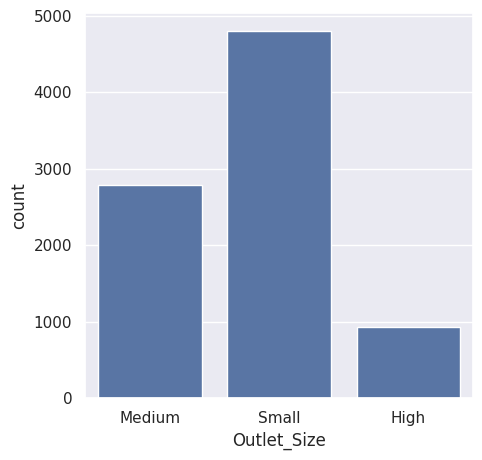

In [33]:
#Outlet_Size distribution
plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Size',data = bigmart_data)
plt.show()

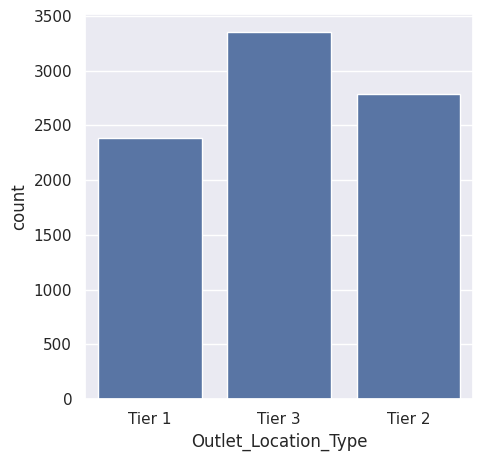

In [34]:
#Outlet_Location_Type distribution
plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Location_Type',data = bigmart_data)
plt.show()

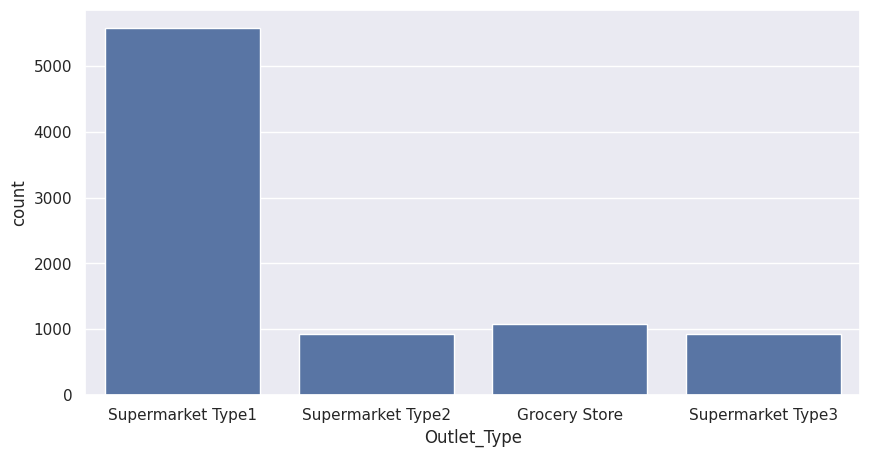

In [35]:
#Outlet_Type distribution
plt.figure(figsize=(10,5))
sns.countplot(x='Outlet_Type',data = bigmart_data)
plt.show()

Data Preprocessing

In [36]:
bigmart_data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [37]:
bigmart_data.replace({'Item_Fat_Content':{'LF':'Low Fat' , 'low fat':'Low Fat' , 'reg':'Regular'}},inplace=True)

In [38]:
bigmart_data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [39]:
#encoder = LabelEncoder()

In [40]:
#bigmart_data['Item_Identifier'] = encoder.fit_transform(bigmart_data['Item_Identifier'])

#bigmart_data['Item_Fat_Content'] = encoder.fit_transform(bigmart_data['Item_Fat_Content'])

#bigmart_data['Item_Type'] = encoder.fit_transform(bigmart_data['Item_Type'])

#bigmart_data['Outlet_Identifier'] = encoder.fit_transform(bigmart_data['Outlet_Identifier'])

#bigmart_data['Outlet_Size'] = encoder.fit_transform(bigmart_data['Outlet_Size'])

#bigmart_data['Outlet_Location_Type'] = encoder.fit_transform(bigmart_data['Outlet_Location_Type'])

#bigmart_data['Outlet_Type'] = encoder.fit_transform(bigmart_data['Outlet_Type'])

In [41]:
bigmart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [42]:
X = bigmart_data.drop(columns='Item_Outlet_Sales',axis=1)
Y = bigmart_data['Item_Outlet_Sales']

In [43]:
print(X)
print(Y)

     Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0              FDA15        9.300          Low Fat         0.016047   
1              DRC01        5.920          Regular         0.019278   
2              FDN15       17.500          Low Fat         0.016760   
3              FDX07       19.200          Regular         0.000000   
4              NCD19        8.930          Low Fat         0.000000   
...              ...          ...              ...              ...   
8518           FDF22        6.865          Low Fat         0.056783   
8519           FDS36        8.380          Regular         0.046982   
8520           NCJ29       10.600          Low Fat         0.035186   
8521           FDN46        7.210          Regular         0.145221   
8522           DRG01       14.800          Low Fat         0.044878   

                  Item_Type  Item_MRP Outlet_Identifier  \
0                     Dairy  249.8092            OUT049   
1               Soft Drinks  

In [44]:
X_train ,X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [45]:
print(X.shape,X_train.shape,X_test.shape)

(8523, 11) (6818, 11) (1705, 11)


Training ML model

In [46]:
#xg_regressor = XGBRegressor()

In [47]:
#xg_regressor.fit(X_train,Y_train)

In [48]:
#training data prediction
#training_data_prediction = xg_regressor.predict(X_train)
# R squared value
#r2_train = metrics.r2_score(Y_train , training_data_prediction)
#print('R squared value : ',r2_train)

In [49]:
#testing data prediction
#testing_data_prediction = xg_regressor.predict(X_test)
# R squared value
#r2_test = metrics.r2_score(Y_test , testing_data_prediction)
#print('R squared value : ',r2_test)

In [50]:
#xg_regressor.feature_importances_

Using XGBoostRegressor we get,

R2 score on Training Data -> 87.5%

R2 score on Testing Data -> 51.5%

difference between training and testing score -> 36%

Using CatboostRegressor directly on categorical columns

In [51]:
!pip install catboost

In [62]:
from catboost import CatBoostRegressor

cat_features = ['Item_Identifier', 'Item_Fat_Content',
                'Item_Type', 'Outlet_Identifier',
                'Outlet_Size', 'Outlet_Location_Type',
                'Outlet_Type']

catboost_regressor = CatBoostRegressor(verbose=0, random_state=2)

catboost_regressor.fit(
    X_train,
    Y_train,
    cat_features=cat_features
)

CatBoostRegressor(loss_function='RMSE', random_state=2, verbose=0)

In [60]:
#training data prediction
training_data_prediction = catboost_regressor.predict(X_train)
# R squared value
r2_train = metrics.r2_score(Y_train , training_data_prediction)
print('R squared value : ',r2_train)
# MAE
mae = metrics.mean_absolute_error(Y_train, training_data_prediction)
print('MAE value : ',mae)
# RMSE
rmse = np.sqrt(metrics.mean_squared_error(Y_train, training_data_prediction))
print('RMSE value : ',rmse)

R squared value :  0.6517155717246632
MAE value :  709.9869259529017
RMSE value :  999.2704365333876


In [61]:
#testing data prediction
testing_data_prediction = catboost_regressor.predict(X_test)
# R squared value
r2_test = metrics.r2_score(Y_test , testing_data_prediction)
print('R squared value : ',r2_test)
# MAE
mae = metrics.mean_absolute_error(Y_test, testing_data_prediction)
print('MAE value : ',mae)
# RMSE
rmse = np.sqrt(metrics.mean_squared_error(Y_test, testing_data_prediction))
print('RMSE value : ',rmse)

R squared value :  0.5830388742001202
MAE value :  791.5884388929829
RMSE value :  1134.5440258993121


In [55]:
catboost_regressor.feature_importances_

array([ 6.18208631,  4.40094883,  0.57273312,  4.76882136,  5.58587888,
       42.4303489 ,  9.44816301,  1.26009061,  5.23741213,  2.14796564,
       17.96555122])

Using CatBoostRegressor we get,

R2 score on Training Data -> 66.2%

R2 score on Testing Data -> 58.8%

difference between training and testing score -> 7.4%

CatBoostRegressor gives a better R2 score on testing data than XGBoostRegressor which was overfitting the data .Also the gap between training and testing data is much smaller in CatBoostRegressor .

So, CatBoostRegressor() performs well on this dataset than the XGBoostRegressor()